In [4]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import libpysal
from esda.moran import Moran
from splot.esda import moran_scatterplot, plot_moran
import warnings
warnings.filterwarnings('ignore')

In [27]:
# Load master table
master = pd.read_csv('data/master_sql.csv', dtype={'county_fips': str, 'state_fips': str})



In [28]:
counties_shp = gpd.read_file('data/county-2020-500k.shp')



In [29]:
print("Master shape:", master.shape)


Master shape: (3059, 11)


In [30]:
print("Shapefile shape:", counties_shp.shape)

Shapefile shape: (3234, 20)


In [31]:
print("Shapefile columns:", counties_shp.columns.tolist())


Shapefile columns: ['STATEFP', 'COUNTYFP', 'COUNTYNS', 'AFFGEOID', 'GEOID', 'NAME', 'NAMELSAD', 'STUSPS', 'STATE_NAME', 'LSAD', 'ALAND', 'AWATER', 'HEROP_ID', 'minx', 'miny', 'maxx', 'maxy', 'BBOX', 'LABEL', 'geometry']


In [32]:
counties_shp = counties_shp.rename(columns={'GEOID': 'county_fips'})

In [33]:
merged = counties_shp.merge(master, on='county_fips', how='inner')

In [34]:
print("Merged shape:", merged.shape)
print("CRS:", merged.crs)

Merged shape: (3056, 30)
CRS: EPSG:4269


In [35]:
print("Null in avg_crude_rate:", merged['avg_crude_rate'].isnull().sum())


Null in avg_crude_rate: 1472


In [36]:
# For Moran's I we can only use counties with real death rate data
# Drop counties where avg_crude_rate is null
merged_clean = merged.dropna(subset=['avg_crude_rate'])
print("Counties with real death data:", len(merged_clean))


Counties with real death data: 1584


In [37]:
# Build spatial weights matrix
# Queen contiguity = counties that share any border or corner are neighbors
w = libpysal.weights.Queen.from_dataframe(merged_clean)


In [38]:
# Row standardize — converts raw counts to proportions
# So each county's neighbors sum to 1 regardless of how many neighbors it has
w.transform = 'r'


('WARNING: ', 8, ' is an island (no neighbors)')
('WARNING: ', 171, ' is an island (no neighbors)')
('WARNING: ', 174, ' is an island (no neighbors)')
('WARNING: ', 179, ' is an island (no neighbors)')
('WARNING: ', 181, ' is an island (no neighbors)')
('WARNING: ', 191, ' is an island (no neighbors)')
('WARNING: ', 228, ' is an island (no neighbors)')
('WARNING: ', 336, ' is an island (no neighbors)')
('WARNING: ', 393, ' is an island (no neighbors)')
('WARNING: ', 394, ' is an island (no neighbors)')
('WARNING: ', 468, ' is an island (no neighbors)')
('WARNING: ', 546, ' is an island (no neighbors)')
('WARNING: ', 567, ' is an island (no neighbors)')
('WARNING: ', 625, ' is an island (no neighbors)')
('WARNING: ', 651, ' is an island (no neighbors)')
('WARNING: ', 672, ' is an island (no neighbors)')
('WARNING: ', 695, ' is an island (no neighbors)')
('WARNING: ', 714, ' is an island (no neighbors)')
('WARNING: ', 729, ' is an island (no neighbors)')
('WARNING: ', 730, ' is an island

In [39]:
print("Spatial weights built")
print("Average number of neighbors per county:", round(w.mean_neighbors, 2))


Spatial weights built
Average number of neighbors per county: 4.18


In [40]:
# Run Moran's I
moran = Moran(merged_clean['avg_crude_rate'], w)

print("=" * 40)
print(f"Moran's I:     {moran.I:.4f}")
print(f"Expected I:    {moran.EI:.4f}")
print(f"p-value:       {moran.p_sim:.4f}")
print(f"z-score:       {moran.z_sim:.4f}")
print("=" * 40)

if moran.p_sim < 0.05:
    print("RESULT: Statistically significant spatial clustering")
    print("Opioid deaths are NOT randomly distributed geographically")
else:
    print("RESULT: No significant spatial clustering detected")

Moran's I:     0.4516
Expected I:    -0.0006
p-value:       0.0010
z-score:       24.3519
RESULT: Statistically significant spatial clustering
Opioid deaths are NOT randomly distributed geographically


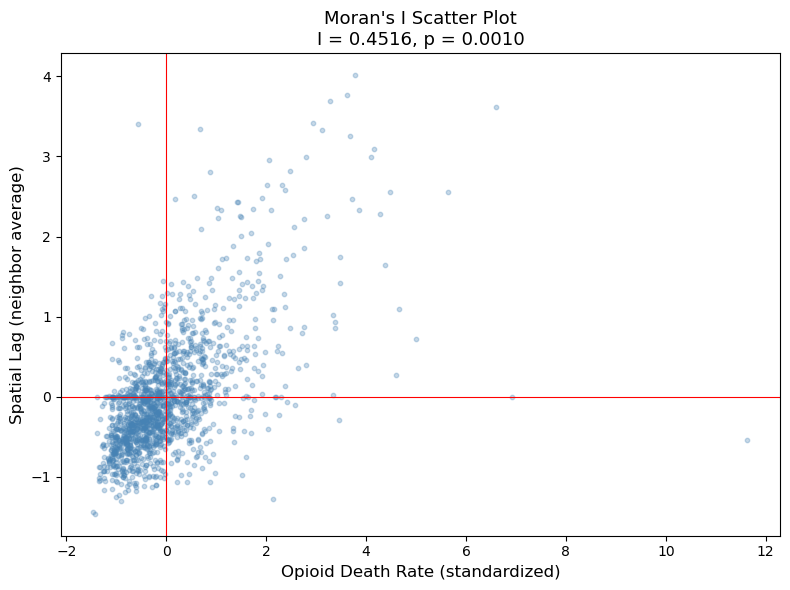

Saved to outputs/morans_i_scatterplot.png


In [41]:
# Visualize Moran's I scatter plot manually
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Standardize the variable
y = merged_clean['avg_crude_rate']
y_std = (y - y.mean()) / y.std()

# Spatial lag — weighted average of neighbors
from libpysal.weights import lag_spatial
y_lag = lag_spatial(w, y_std)

# Plot
ax.scatter(y_std, y_lag, alpha=0.3, color='steelblue', s=10)
ax.axhline(0, color='red', linewidth=0.8)
ax.axvline(0, color='red', linewidth=0.8)
ax.set_xlabel("Opioid Death Rate (standardized)", fontsize=12)
ax.set_ylabel("Spatial Lag (neighbor average)", fontsize=12)
ax.set_title(f"Moran's I Scatter Plot\nI = {moran.I:.4f}, p = {moran.p_sim:.4f}", fontsize=13)

plt.tight_layout()
plt.savefig('outputs/morans_i_scatterplot.png', dpi=150)
plt.show()
print("Saved to outputs/morans_i_scatterplot.png")

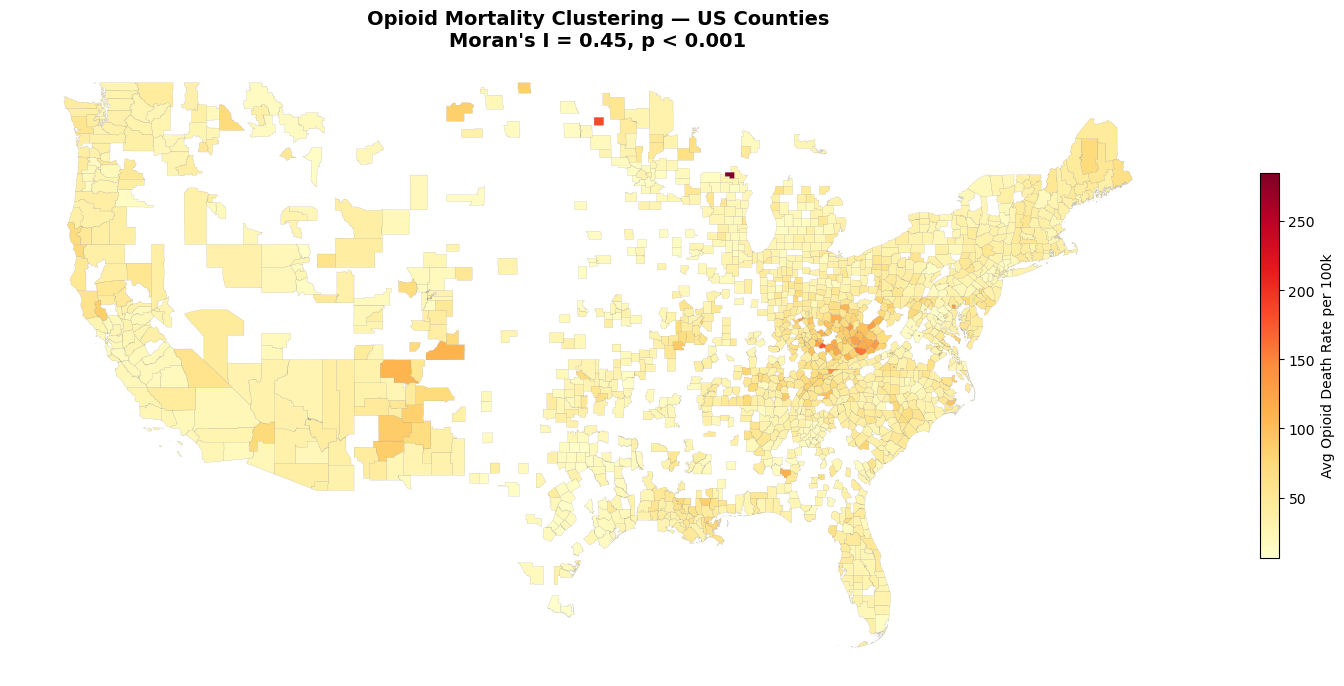

Saved to outputs/mortality_map.png


In [42]:
fig, ax = plt.subplots(1, 1, figsize=(15, 8))

# Plot counties colored by death rate
# Drop Alaska and Hawaii for cleaner continental US map
continental = merged_clean[~merged_clean['state_fips'].isin(['02', '15', '72'])]

continental.plot(
    column='avg_crude_rate',
    cmap='YlOrRd',
    linewidth=0.1,
    edgecolor='grey',
    legend=True,
    legend_kwds={'label': 'Avg Opioid Death Rate per 100k', 'shrink': 0.5},
    missing_kwds={'color': 'lightgrey'},
    ax=ax
)

ax.set_title("Opioid Mortality Clustering — US Counties\nMoran's I = 0.45, p < 0.001", 
             fontsize=14, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.savefig('outputs/mortality_map.png', dpi=150)
plt.show()
print("Saved to outputs/mortality_map.png")

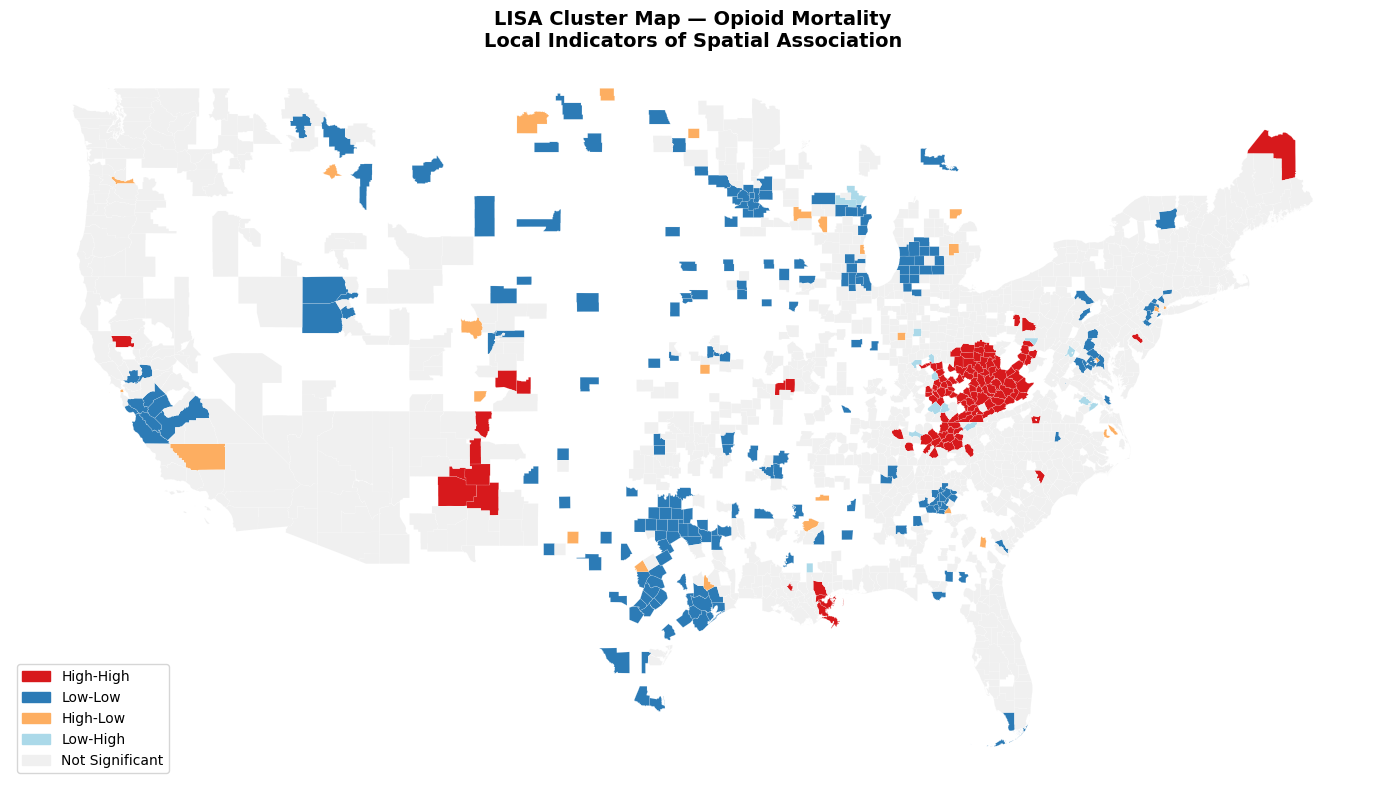


Cluster counts:
  Not Significant: 1195 counties
  Low-Low: 221 counties
  High-Low: 30 counties
  High-High: 123 counties
  Low-High: 15 counties


In [43]:
from esda.moran import Moran_Local
import matplotlib.patches as mpatches

# Calculate Local Moran's I for each county
lisa = Moran_Local(merged_clean['avg_crude_rate'], w)

# Classify each county
# lisa.q gives quadrant: 1=HH, 2=LH, 3=LL, 4=HL
# lisa.p_sim gives significance

significance = 0.05
labels = []

for i in range(len(lisa.p_sim)):
    if lisa.p_sim[i] < significance:
        if lisa.q[i] == 1:
            labels.append('High-High')
        elif lisa.q[i] == 2:
            labels.append('Low-High')
        elif lisa.q[i] == 3:
            labels.append('Low-Low')
        elif lisa.q[i] == 4:
            labels.append('High-Low')
    else:
        labels.append('Not Significant')

merged_clean = merged_clean.copy()
merged_clean['lisa_label'] = labels

# Plot
color_map = {
    'High-High': '#d7191c',      # Red
    'Low-Low': '#2c7bb6',        # Blue
    'High-Low': '#fdae61',       # Orange
    'Low-High': '#abd9e9',       # Light blue
    'Not Significant': '#f0f0f0' # Grey
}

fig, ax = plt.subplots(1, 1, figsize=(15, 8))

continental = merged_clean[~merged_clean['state_fips'].isin(['02', '15', '72'])]

for label, color in color_map.items():
    subset = continental[continental['lisa_label'] == label]
    if len(subset) > 0:
        subset.plot(ax=ax, color=color, linewidth=0.1, edgecolor='white')

# Legend
patches = [mpatches.Patch(color=color, label=label) 
           for label, color in color_map.items()]
ax.legend(handles=patches, loc='lower left', fontsize=10)

ax.set_title("LISA Cluster Map — Opioid Mortality\nLocal Indicators of Spatial Association", 
             fontsize=14, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.savefig('outputs/lisa_cluster_map.png', dpi=150)
plt.show()

# Print counts
from collections import Counter
print("\nCluster counts:")
for label, count in Counter(labels).items():
    print(f"  {label}: {count} counties")

In [44]:
from collections import Counter
print("\nCluster counts:")
for label, count in Counter(labels).items():
    print(f"  {label}: {count} counties")


Cluster counts:
  Not Significant: 1195 counties
  Low-Low: 221 counties
  High-Low: 30 counties
  High-High: 123 counties
  Low-High: 15 counties


In [45]:
# Add lisa_label back to master table
lisa_features = merged_clean[['county_fips', 'lisa_label']].copy()
master = pd.read_csv('data/master_sql.csv', dtype={'county_fips': str})
master = master.merge(lisa_features, on='county_fips', how='left')
master['lisa_label'] = master['lisa_label'].fillna('Not Significant')
print("Master shape after LISA:", master.shape)
print(master['lisa_label'].value_counts())


Master shape after LISA: (3059, 12)
lisa_label
Not Significant    2670
Low-Low             221
High-High           123
High-Low             30
Low-High             15
Name: count, dtype: int64


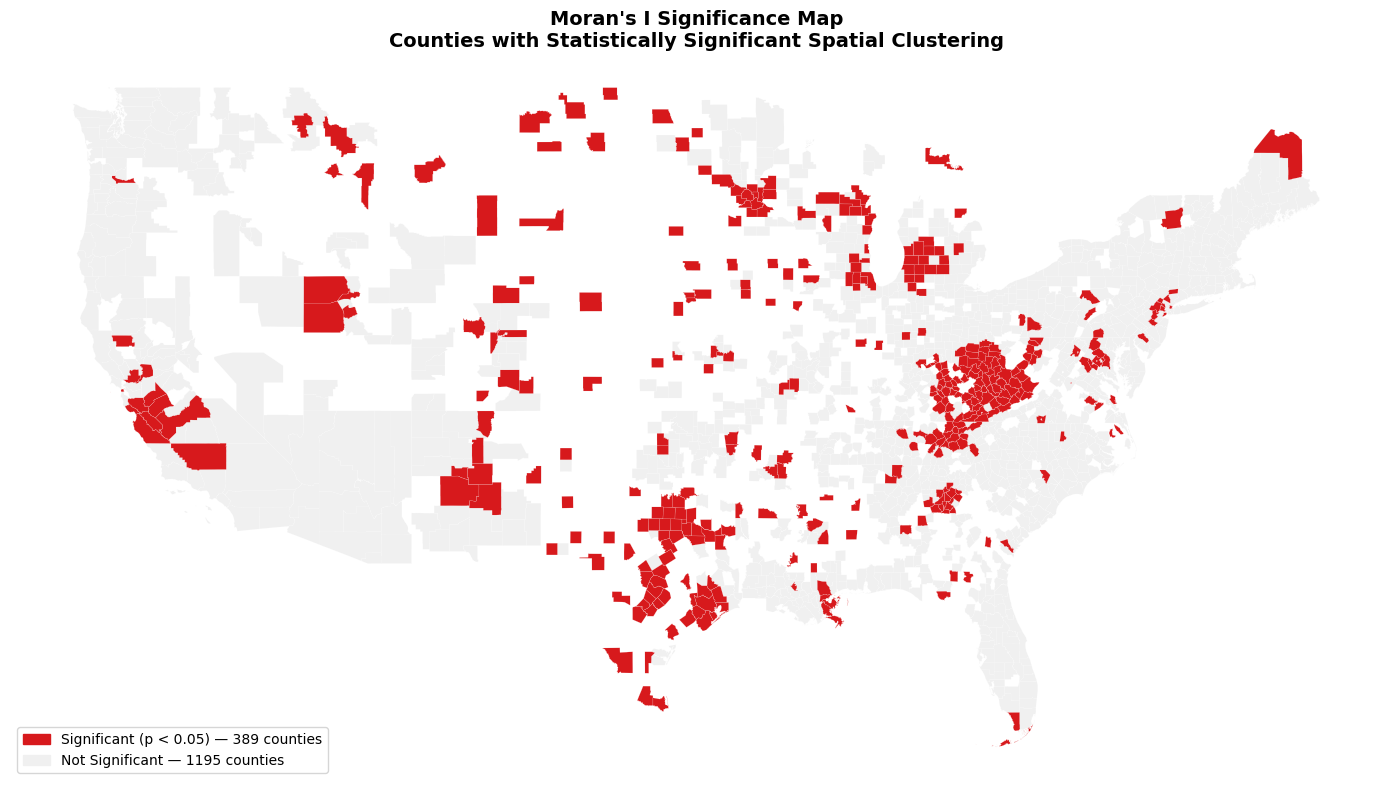

Saved to outputs/morans_significance_map.png


In [46]:
fig, ax = plt.subplots(1, 1, figsize=(15, 8))

# Create significance column
merged_clean = merged_clean.copy()
merged_clean['significant'] = (lisa.p_sim < 0.05).astype(int)

continental = merged_clean[~merged_clean['state_fips'].isin(['02', '15', '72'])]

# Plot non-significant first (background)
continental[continental['significant'] == 0].plot(
    ax=ax,
    color='#f0f0f0',
    linewidth=0.1,
    edgecolor='white'
)

# Plot significant counties on top
continental[continental['significant'] == 1].plot(
    ax=ax,
    color='#d7191c',
    linewidth=0.1,
    edgecolor='white'
)

# Legend
patches = [
    mpatches.Patch(color='#d7191c', label=f'Significant (p < 0.05) — {merged_clean["significant"].sum()} counties'),
    mpatches.Patch(color='#f0f0f0', label=f'Not Significant — {(merged_clean["significant"] == 0).sum()} counties')
]
ax.legend(handles=patches, loc='lower left', fontsize=10)

ax.set_title("Moran's I Significance Map\nCounties with Statistically Significant Spatial Clustering", 
             fontsize=14, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.savefig('outputs/morans_significance_map.png', dpi=150)
plt.show()
print("Saved to outputs/morans_significance_map.png")

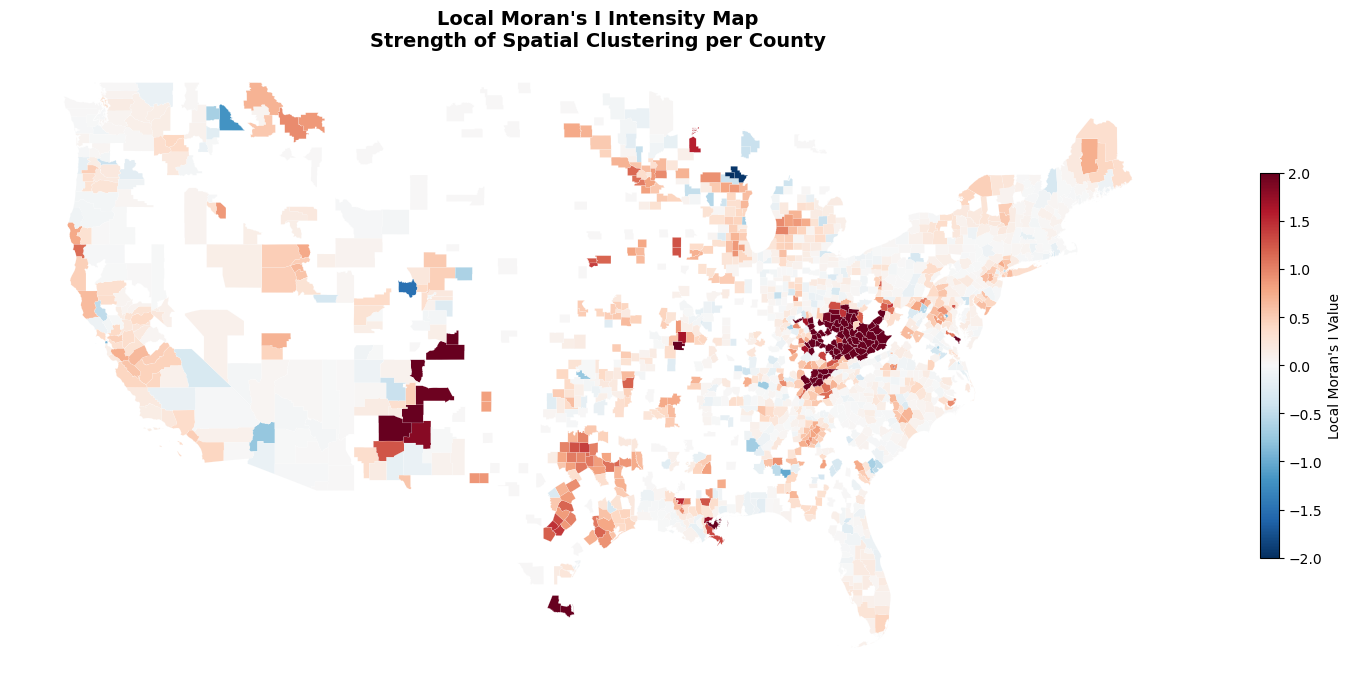

Saved to outputs/local_morans_intensity_map.png


In [47]:
fig, ax = plt.subplots(1, 1, figsize=(15, 8))

# Add local moran's I values to dataframe
merged_clean = merged_clean.copy()
merged_clean['local_i'] = lisa.Is

continental = merged_clean[~merged_clean['state_fips'].isin(['02', '15', '72'])]

continental.plot(
    column='local_i',
    cmap='RdBu_r',
    linewidth=0.1,
    edgecolor='white',
    legend=True,
    legend_kwds={
        'label': "Local Moran's I Value",
        'shrink': 0.5
    },
    vmin=-2,
    vmax=2,
    ax=ax
)

ax.set_title("Local Moran's I Intensity Map\nStrength of Spatial Clustering per County", 
             fontsize=14, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.savefig('outputs/local_morans_intensity_map.png', dpi=150)
plt.show()
print("Saved to outputs/local_morans_intensity_map.png")

In [48]:
master.to_csv('data/master_with_lisa.csv', index=False)
print("Saved master_with_lisa.csv")


Saved master_with_lisa.csv


In [49]:
import os
files = os.listdir('data/')
print(files)

['cdc_clean.csv', 'oeps_pharmacy_merged.csv', '.DS_Store', 'master_county.csv', 'oeps_tract_clean.csv', 'cdc_overdose_deaths.csv', 'county-2020-500k.prj', 'tract-2020-500k.shp', 'master_engineered.csv', 'master_with_lisa.csv', 'census_acs_dp03.csv', 'target.csv', 'oeps_county_clean.csv', 'county-2020-500k.dbf', 'master_sql.csv', '.ipynb_checkpoints', 'features.csv', 'county-2020-500k.cpg', 'county-2020-500k.shp', 'county-2020-500k.shx', 'census_clean.csv', 'Pharmacy (3).csv']


In [50]:
pharmacies = pd.read_csv('data/Pharmacy (3).csv')
print("Shape:", pharmacies.shape)
print("Columns:", pharmacies.columns.tolist())
print("\nFirst few rows:")
print(pharmacies.head())
print("\nNull counts:")
print(pharmacies[['lat', 'lon']].isnull().sum())


Shape: (40135, 8)
Columns: ['name', 'address', 'city', 'state', 'zip', 'confidence', 'lon', 'lat']

First few rows:
                 name           address       city state    zip  confidence  \
0  Raincity Drugstore       305 Dock St  Ketchikan    AK  99901        0.96   
1             Safeway  2417 Tongass Ave  Ketchikan    AK  99901        0.97   
2      Carrs Pharmacy  2417 Tongass Ave  Ketchikan    AK  99901        0.96   
3     Island Pharmacy  3526 Tongass Ave  Ketchikan    AK  99901        0.99   
4             Walmart  4230 Don King Rd  Ketchikan    AK  99901        0.95   

          lon        lat  
0 -131.647307  55.342034  
1 -131.674002  55.348324  
2 -131.673742  55.348399  
3 -131.692653  55.355862  
4 -131.720571  55.375468  

Null counts:
lat    0
lon    0
dtype: int64


In [51]:
# Get county centroids from shapefile
centroids = merged_clean[['county_fips', 'geometry']].copy()

# .centroid extracts the center point of each polygon
centroids['centroid'] = centroids.geometry.centroid

# Extract lat and lon from the centroid point
centroids['cent_lat'] = centroids.centroid.y   # y = latitude
centroids['cent_lon'] = centroids.centroid.x   # x = longitude

print("County centroids ready:", len(centroids))
print(centroids[['county_fips', 'cent_lat', 'cent_lon']].head())

County centroids ready: 1584
  county_fips   cent_lat   cent_lon
0       13031  32.396810 -81.743167
1       13121  33.790244 -84.467010
2       13179  31.828233 -81.494900
4       13213  34.788430 -84.748072
6       13139  34.316899 -83.819679


In [52]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in kilometers
    
    # Convert degrees to radians — math functions need radians
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    
    # Difference between the two points
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    # Core haversine formula
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    
    # Convert angular distance to kilometers
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

# Test it — distance between two known points
# New York to Los Angeles should be roughly 3,940 km
test_dist = haversine(40.7128, -74.0060, 34.0522, -118.2437)
print(f"NY to LA: {test_dist:.1f} km")
print("Expected: ~3940 km")

NY to LA: 3935.7 km
Expected: ~3940 km


In [53]:
import numpy as np

# Convert pharmacy coordinates to numpy arrays for fast computation
pharmacy_lats = pharmacies['lat'].values
pharmacy_lons = pharmacies['lon'].values

def get_top5_candidates(cent_lat, cent_lon):
    # Calculate haversine distance to ALL pharmacies at once
    # Using vectorized numpy — much faster than a loop
    R = 6371
    
    lat1 = radians(cent_lat)
    lon1 = radians(cent_lon)
    lat2 = np.radians(pharmacy_lats)
    lon2 = np.radians(pharmacy_lons)
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    distances = R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    
    # Get indices of 5 smallest distances
    top5_idx = np.argpartition(distances, 5)[:5]
    
    return top5_idx, distances[top5_idx]

# Test on first county
test_county = centroids.iloc[0]
idx, dists = get_top5_candidates(test_county['cent_lat'], test_county['cent_lon'])

print(f"County: {test_county['county_fips']}")
print(f"Top 5 nearest pharmacies (straight line):")
for i, (pharmacy_idx, dist) in enumerate(zip(idx, dists)):
    print(f"  {i+1}. {pharmacies.iloc[pharmacy_idx]['name']} — {dist:.1f} km")

County: 13031
Top 5 nearest pharmacies (straight line):
  1. Southern Pharmacy — 4.8 km
  2. Walgreens — 5.2 km
  3. Walker Pharmacy — 3.0 km
  4. McCook's Pharmacy — 3.8 km
  5. Guardian Pharmacy of South Georgia — 7.2 km


In [54]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Get Bacon County centroid
test_county = centroids[centroids['county_fips'] == '13031'].iloc[0]
cent_lat = test_county['cent_lat']
cent_lon = test_county['cent_lon']

print(f"County: 13031 — Bacon County GA")
print(f"Centroid: ({cent_lat:.4f}, {cent_lon:.4f})")

# Download road network within 50km radius
print("\nDownloading road network from OpenStreetMap...")
G = ox.graph_from_point(
    (cent_lat, cent_lon),  # center point
    dist=50000,             # 50km radius
    network_type='drive'    # only driveable roads
)

print(f"Road network downloaded")
print(f"Number of intersections (nodes): {len(G.nodes)}")
print(f"Number of road segments (edges): {len(G.edges)}")

County: 13031 — Bacon County GA
Centroid: (32.3968, -81.7432)

Road network downloaded
Number of intersections (nodes): 22245
Number of road segments (edges): 56432


In [55]:
# Get top 5 candidate pharmacies for this county
idx, dists = get_top5_candidates(cent_lat, cent_lon)
top5_pharmacies = pharmacies.iloc[idx].copy()
top5_pharmacies['straight_line_km'] = dists

print("Top 5 candidates:")
print(top5_pharmacies[['name', 'lat', 'lon', 'straight_line_km']].to_string())

# Snap county centroid to nearest road node
centroid_node = ox.nearest_nodes(G, cent_lon, cent_lat)
print(f"\nCentroid snapped to node: {centroid_node}")

# For each pharmacy find nearest node and shortest path distance
results = []

for _, pharmacy in top5_pharmacies.iterrows():
    try:
        # Snap pharmacy to nearest road node
        pharmacy_node = ox.nearest_nodes(G, pharmacy['lon'], pharmacy['lat'])
        
        # Run Dijkstra shortest path — returns distance in meters
        path_length = nx.shortest_path_length(
            G, 
            centroid_node, 
            pharmacy_node, 
            weight='length'
        )
        
        results.append({
            'name': pharmacy['name'],
            'straight_line_km': pharmacy['straight_line_km'],
            'road_distance_km': path_length / 1000,  # convert meters to km
            'pharmacy_lat': pharmacy['lat'],
            'pharmacy_lon': pharmacy['lon'],
            'pharmacy_node': pharmacy_node
        })
        
        print(f"{pharmacy['name']}: {pharmacy['straight_line_km']:.1f}km straight → {path_length/1000:.1f}km by road")
        
    except Exception as e:
        print(f"{pharmacy['name']}: FAILED — {e}")

# Find nearest by road
results_df = pd.DataFrame(results)
nearest = results_df.loc[results_df['road_distance_km'].idxmin()]
print(f"\nNearest pharmacy by road: {nearest['name']} at {nearest['road_distance_km']:.1f}km")


Top 5 candidates:
                                    name        lat        lon  straight_line_km
8908                   Southern Pharmacy  32.434362 -81.767682          4.767764
8909                           Walgreens  32.439744 -81.765113          5.199548
8906                     Walker Pharmacy  32.411380 -81.769990          2.994324
8907                   McCook's Pharmacy  32.430855 -81.747859          3.811207
8899  Guardian Pharmacy of South Georgia  32.398823 -81.819748          7.193450

Centroid snapped to node: 11549014522
Southern Pharmacy: 4.8km straight → 5.6km by road
Walgreens: 5.2km straight → 6.0km by road
Walker Pharmacy: 3.0km straight → 4.3km by road
McCook's Pharmacy: 3.8km straight → 4.7km by road
Guardian Pharmacy of South Georgia: 7.2km straight → 8.2km by road

Nearest pharmacy by road: Walker Pharmacy at 4.3km


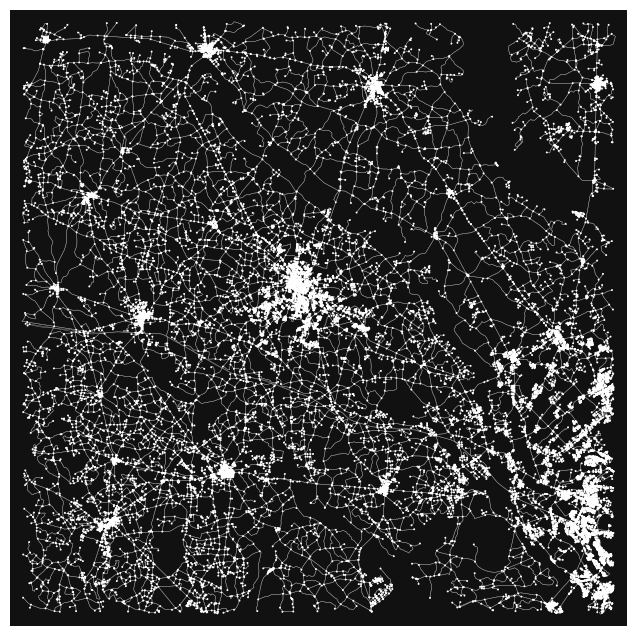

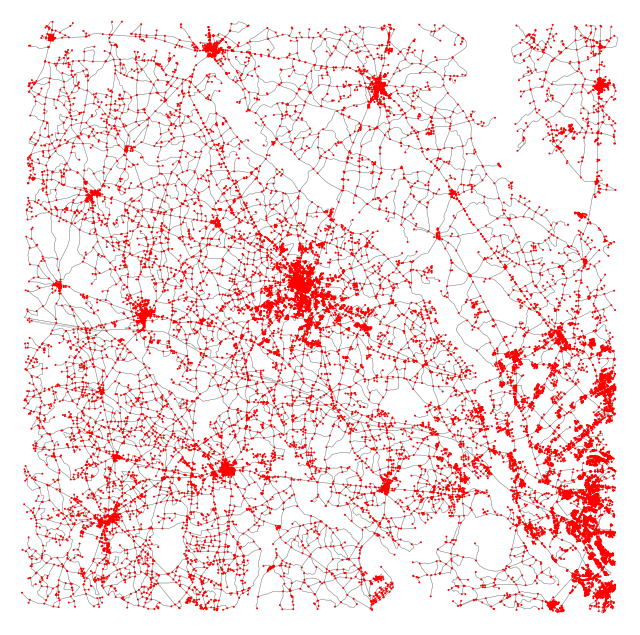

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [56]:
ox.plot_graph(G,node_size=2, edge_linewidth=0.3)
G_projected = ox.project_graph(G)
ox.plot_graph(G_projected,node_size=2, edge_linewidth=0.3,bgcolor='white',node_color='red')

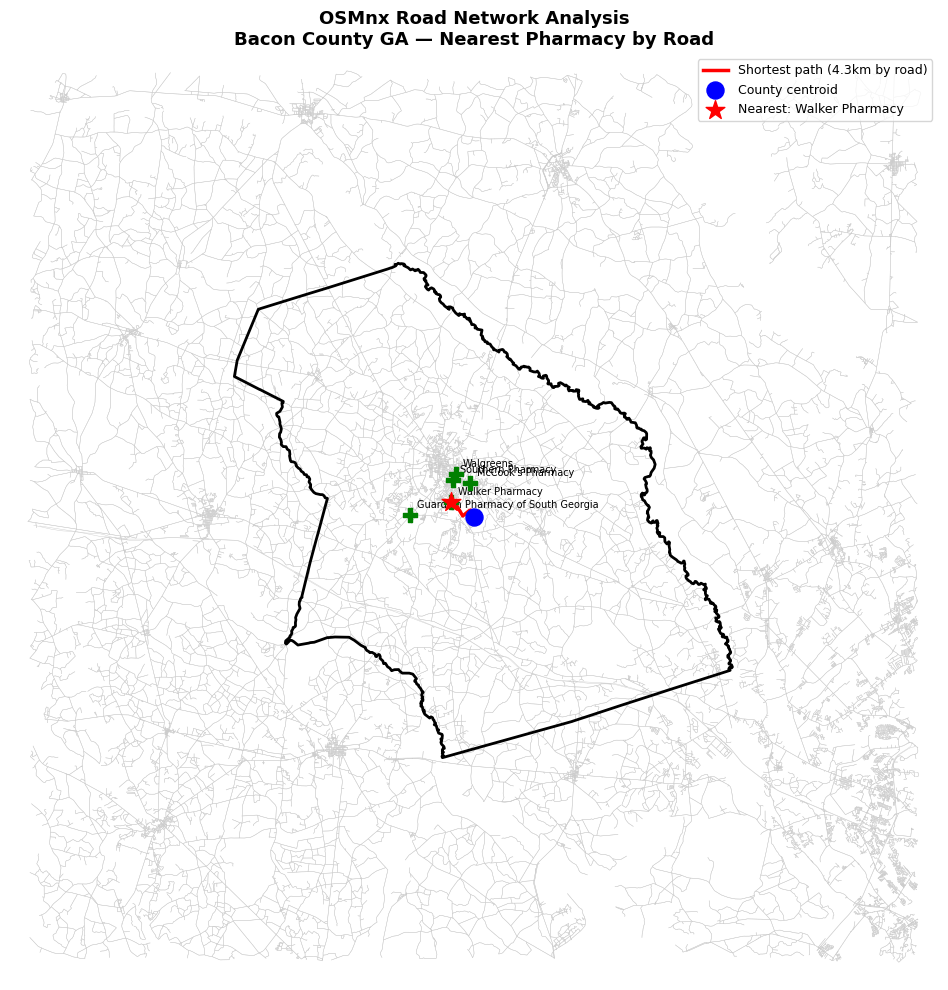

Saved to outputs/osmnx_bacon_county.png


In [57]:
# Get the actual shortest path for visualization
nearest_node = int(nearest['pharmacy_node'])
shortest_path = nx.shortest_path(G, centroid_node, nearest_node, weight='length')

# Plot everything
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot road network
ox.plot_graph(G, ax=ax, node_size=0, edge_linewidth=0.3, 
              edge_color='#cccccc', show=False, close=False)

# Plot county boundary
county_boundary = merged_clean[merged_clean['county_fips'] == '13031']
county_boundary.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=2)

# Plot shortest path on top
path_nodes = [(G.nodes[n]['x'], G.nodes[n]['y']) for n in shortest_path]
path_lons, path_lats = zip(*path_nodes)
ax.plot(path_lons, path_lats, color='red', linewidth=2.5, 
        zorder=5, label=f'Shortest path ({nearest["road_distance_km"]:.1f}km by road)')

# Plot county centroid
ax.scatter(cent_lon, cent_lat, c='blue', s=150, zorder=6, 
           label='County centroid')

# Plot all 5 candidate pharmacies
for _, p in top5_pharmacies.iterrows():
    ax.scatter(p['lon'], p['lat'], c='green', s=100, zorder=6, marker='P')
    ax.annotate(p['name'], (p['lon'], p['lat']), 
                fontsize=7, xytext=(5, 5), textcoords='offset points')

# Highlight nearest pharmacy
ax.scatter(nearest['pharmacy_lon'], nearest['pharmacy_lat'], 
           c='red', s=200, zorder=7, marker='*',
           label=f'Nearest: {nearest["name"]}')

ax.set_title(f"OSMnx Road Network Analysis\nBacon County GA — Nearest Pharmacy by Road", 
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/osmnx_bacon_county.png', dpi=150)
plt.show()
print("Saved to outputs/osmnx_bacon_county.png")

In [58]:
import psutil
ram = psutil.virtual_memory()
print(f"Total RAM: {ram.total / (1024**3):.1f} GB")
print(f"Available RAM: {ram.available / (1024**3):.1f} GB")

Total RAM: 24.0 GB
Available RAM: 4.7 GB


In [59]:
import osmnx as ox
import gc
import psutil
import time

# Configure OSMnx
ox.settings.log_console = False      # don't print logs for every download
ox.settings.use_cache = True         # cache networks to disk not RAM
ox.settings.cache_folder = 'data/osmnx_cache'  # where to store cache

# Verify memory function
def get_available_ram():
    return psutil.virtual_memory().available / (1024**3)

print(f"Available RAM before starting: {get_available_ram():.1f} GB")
print("OSMnx configured")

Available RAM before starting: 4.7 GB
OSMnx configured


In [60]:
# Prepare ArcGIS upload file
arcgis_data = merged_clean[[
    'county_fips', 'geometry',
    'avg_crude_rate', 'suppressed_years',
    'pharmacy_desert', 'phar_tm_dr_p', 'phar_av_tm_dr',
    'poverty_rate', 'unemployment_rate', 
    'median_income', 'uninsured_rate',
    'lisa_label'
]].copy()

# Drop nulls in avg_crude_rate for clean analysis
arcgis_data = arcgis_data.dropna(subset=['avg_crude_rate'])

print("ArcGIS data shape:", arcgis_data.shape)
print("CRS:", arcgis_data.crs)
print(arcgis_data.head())

ArcGIS data shape: (1584, 12)
CRS: EPSG:4269
  county_fips                                           geometry  \
0       13031  POLYGON ((-82.02684 32.55516, -82.02527 32.558...   
1       13121  POLYGON ((-84.84931 33.51318, -84.84429 33.514...   
2       13179  POLYGON ((-81.8244 32.01488, -81.81338 32.0162...   
4       13213  POLYGON ((-84.94434 34.68004, -84.9431 34.6804...   
6       13139  POLYGON ((-84.06225 34.16845, -84.05949 34.175...   

   avg_crude_rate  suppressed_years  pharmacy_desert  phar_tm_dr_p  \
0       13.866667               4.0              0.0        100.00   
1       23.171429               0.0              0.0         99.69   
2       25.750000               3.0              0.0        100.00   
4       27.433333               4.0              0.0         90.00   
6       24.342857               0.0              0.0        100.00   

   phar_av_tm_dr  poverty_rate  unemployment_rate  median_income  \
0           6.45          22.5                7.9        

In [98]:
import os

# ArcGIS needs WGS84 (EPSG:4326) not NAD83 (EPSG:4269)
arcgis_data = arcgis_data.to_crs(epsg=4326)

# Shapefiles can't have column names longer than 10 characters
# Rename long columns
arcgis_data = arcgis_data.rename(columns={
    'avg_crude_rate'    : 'mort_rate',
    'suppressed_years'  : 'suppress',
    'pharmacy_desert'   : 'ph_desert',
    'phar_tm_dr_p'      : 'ph_pct',
    'phar_av_tm_dr'     : 'ph_avgtm',
    'poverty_rate'      : 'pov_rate',
    'unemployment_rate' : 'unemp_rate',
    'median_income'     : 'med_inc',
    'uninsured_rate'    : 'unins_rate',
    'lisa_label'        : 'lisa'
})

# Save as shapefile
output_dir = os.path.expanduser('~/Documents/Last mile/data/arcgis_upload')
os.makedirs(output_dir, exist_ok=True)
arcgis_data.to_file(f'{output_dir}/last_mile_counties.shp')

print("Saved shapefile to:", output_dir)
print("Files created:")
for f in os.listdir(output_dir):
    print(f'  {f}')

Saved shapefile to: /Users/sanket/Documents/Last mile/data/arcgis_upload
Files created:
  last_mile_counties.prj
  last_mile_counties.shx
  last_mile_counties.cpg
  last_mile_counties.shp
  last_mile_counties.dbf


In [100]:
import zipfile
import os

output_dir = os.path.expanduser('~/Documents/Last mile/data/arcgis_upload')
zip_path   = os.path.expanduser('~/Documents/Last mile/data/last_mile_counties.zip')

with zipfile.ZipFile(zip_path, 'w') as zf:
    for f in os.listdir(output_dir):
        zf.write(os.path.join(output_dir, f), f)

print(f'Zipped to: {zip_path}')

Zipped to: /Users/sanket/Documents/Last mile/data/last_mile_counties.zip


In [104]:
hotspots = pd.read_csv('data/HotSpotsOutput_0.csv')
print(hotspots.shape)
print(hotspots.columns.tolist())
print(hotspots.head(10))

(1584, 8)
['OBJECTID', 'SOURCE_ID', 'mort_rate', 'GiPValue Fixed 345201', 'GiZScore Fixed 345201', 'Gi_Bin Fixed 345201_FDR', 'Statistical Significance', 'NNeighbors Fixed 345201']
   OBJECTID  SOURCE_ID  mort_rate  GiPValue Fixed 345201  \
0         1          1  13.866667           3.558267e-02   
1         2          2  23.171429           1.731924e-01   
2         3          3  25.750000           9.681090e-02   
3         4          4  27.433333           1.100000e-07   
4         5          5  24.342857           1.015239e-02   
5         6          6  42.114286           7.147196e-01   
6         7          7  21.385714           1.273185e-01   
7         8          8  32.300000           2.134200e-03   
8         9          9  40.500000           1.715876e-02   
9        10         10  44.800000           7.690814e-01   

   GiZScore Fixed 345201  Gi_Bin Fixed 345201_FDR  \
0              -2.101665                       -1   
1               1.362018                        0   

In [106]:
# Reset index to get sequential numbers
arcgis_data_reset = arcgis_data.reset_index(drop=True)
arcgis_data_reset['SOURCE_ID'] = arcgis_data_reset.index + 1

# Check alignment — mort_rate should match between both files
print("ArcGIS data first 5 mort_rate values:")
print(arcgis_data_reset[['SOURCE_ID', 'county_fips', 'mort_rate']].head())

print("\nHotspot file first 5 mort_rate values:")
print(hotspots[['SOURCE_ID', 'mort_rate']].head())


ArcGIS data first 5 mort_rate values:
   SOURCE_ID county_fips  mort_rate
0          1       13031  13.866667
1          2       13121  23.171429
2          3       13179  25.750000
3          4       13213  27.433333
4          5       13139  24.342857

Hotspot file first 5 mort_rate values:
   SOURCE_ID  mort_rate
0          1  13.866667
1          2  23.171429
2          3  25.750000
3          4  27.433333
4          5  24.342857


In [108]:
# Merge county_fips into hotspots using SOURCE_ID
hotspots_merged = hotspots.merge(
    arcgis_data_reset[['SOURCE_ID', 'county_fips']],
    on='SOURCE_ID',
    how='left'
)

# Keep only what we need
hotspots_clean = hotspots_merged[['county_fips', 
                                   'GiZScore Fixed 345201',
                                   'GiPValue Fixed 345201',
                                   'Statistical Significance']].copy()

# Rename columns
hotspots_clean = hotspots_clean.rename(columns={
    'GiZScore Fixed 345201'  : 'gi_zscore',
    'GiPValue Fixed 345201'  : 'gi_pvalue',
    'Statistical Significance': 'hotspot_label'
})

print("Hotspots clean shape:", hotspots_clean.shape)
print("\nHotspot distribution:")
print(hotspots_clean['hotspot_label'].value_counts())

Hotspots clean shape: (1584, 4)

Hotspot distribution:
hotspot_label
Not Significant                  597
Hot Spot with 99% Confidence     432
Cold Spot with 99% Confidence    295
Cold Spot with 95% Confidence     93
Cold Spot with 90% Confidence     91
Hot Spot with 95% Confidence      44
Hot Spot with 90% Confidence      32
Name: count, dtype: int64


In [110]:
# Load master with lisa
master = pd.read_csv('data/master_with_lisa.csv', dtype={'county_fips': str})

# Merge hotspot labels
master_final = master.merge(
    hotspots_clean,
    on='county_fips',
    how='left'
)

# Fill counties with no hotspot data
master_final['hotspot_label'] = master_final['hotspot_label'].fillna('No Data')

print("Master final shape:", master_final.shape)
print("\nNull counts in new columns:")
print(master_final[['gi_zscore', 'gi_pvalue', 'hotspot_label']].isnull().sum())
print("\nHotspot distribution in master:")
print(master_final['hotspot_label'].value_counts())

# Save
master_final.to_csv('data/master_with_hotspots.csv', index=False)
print("\nSaved to master_with_hotspots.csv")

Master final shape: (3059, 15)

Null counts in new columns:
gi_zscore        1475
gi_pvalue        1475
hotspot_label       0
dtype: int64

Hotspot distribution in master:
hotspot_label
No Data                          1475
Not Significant                   597
Hot Spot with 99% Confidence      432
Cold Spot with 99% Confidence     295
Cold Spot with 95% Confidence      93
Cold Spot with 90% Confidence      91
Hot Spot with 95% Confidence       44
Hot Spot with 90% Confidence       32
Name: count, dtype: int64

Saved to master_with_hotspots.csv


In [6]:
osmnx_results = pd.read_csv('data/osmnx_results.csv', dtype={'county_fips': str})

In [8]:
print("Shape:", osmnx_results.shape)


Shape: (1580, 5)


In [10]:
print("\nColumns:", osmnx_results.columns.tolist())



Columns: ['county_fips', 'nearest_pharm_name', 'straight_line_km', 'road_distance_km', 'method']


In [12]:
print("\nMethod breakdown:")



Method breakdown:


In [14]:
print(osmnx_results['method'].value_counts())

method
osmnx                 1579
haversine_fallback       1
Name: count, dtype: int64


In [16]:
print("\nRoad distance stats:")


Road distance stats:


In [18]:
print(osmnx_results['road_distance_km'].describe())


count    1577.000000
mean       10.773301
std        15.897424
min         0.000000
25%         2.841000
50%         6.370000
75%        12.245000
max       218.834000
Name: road_distance_km, dtype: float64


In [20]:
print("\nSample:")



Sample:


In [22]:
print(osmnx_results.head(10))

  county_fips        nearest_pharm_name  straight_line_km  road_distance_km  \
0       13031           Walker Pharmacy             2.994             4.348   
1       13121        Poly-Plex Pharmacy             1.715             2.070   
2       13179                CVS Beauty             9.744            12.545   
3       13213              Corner Drugs             2.749             4.337   
4       13139              CVS Pharmacy             0.406             0.388   
5       13245                 Walgreens             1.968             2.907   
6       13157  Crawford W Long Pharmacy             1.892             2.065   
7       13177                CVS Beauty            13.906            14.831   
8       13279     Walker Pharmacy Lyons             8.722            12.245   
9       34015                 Walgreens             2.945             3.347   

  method  
0  osmnx  
1  osmnx  
2  osmnx  
3  osmnx  
4  osmnx  
5  osmnx  
6  osmnx  
7  osmnx  
8  osmnx  
9  osmnx  


In [24]:
master = pd.read_csv('data/master_with_hotspots.csv', dtype={'county_fips': str})

In [26]:
master_final = master.merge(
    osmnx_results[['county_fips', 'nearest_pharm_name', 
                   'straight_line_km', 'road_distance_km', 'method']],
    on='county_fips',
    how='left'
)

In [28]:
print("Master final shape:", master_final.shape)
print("\nColumns:", master_final.columns.tolist())
print("\nNull counts:")
print(master_final.isnull().sum())


Master final shape: (3059, 19)

Columns: ['county_fips', 'state_fips', 'avg_crude_rate', 'suppressed_years', 'phar_tm_dr_p', 'phar_av_tm_dr', 'pharmacy_desert', 'poverty_rate', 'unemployment_rate', 'median_income', 'uninsured_rate', 'lisa_label', 'gi_zscore', 'gi_pvalue', 'hotspot_label', 'nearest_pharm_name', 'straight_line_km', 'road_distance_km', 'method']

Null counts:
county_fips              0
state_fips               0
avg_crude_rate        1475
suppressed_years         0
phar_tm_dr_p             3
phar_av_tm_dr           36
pharmacy_desert          3
poverty_rate            11
unemployment_rate       11
median_income           11
uninsured_rate          11
lisa_label               0
gi_zscore             1475
gi_pvalue             1475
hotspot_label            0
nearest_pharm_name    1481
straight_line_km      1481
road_distance_km      1482
method                1479
dtype: int64


In [30]:
master_final.to_csv('data/master_final.csv', index=False)
print("\nSaved to master_final.csv")


Saved to master_final.csv
